In [1]:
# ============================================================
# CELL 1: SETUP
# ============================================================
import os, re, gc, copy, time, random, warnings, json
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T

from sklearn.metrics import (
    classification_report, confusion_matrix,
    balanced_accuracy_score, accuracy_score
)
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(s=SEED):
    random.seed(s); np.random.seed(s)
    os.environ['PYTHONHASHSEED'] = str(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Device: cuda
GPU: Tesla P100-PCIE-16GB
VRAM: 17.1 GB


In [2]:
# ============================================================
# CELL 2: CONFIGURATION
# ============================================================
class CFG:
    data_root = "/kaggle/input/datasets/aryashah2k/endoscopic-bladder-tissue-classification-dataset/EndoscopicBladderTissue"

    # Target patient for testing
    target_patient = 7
    
    class_names = ['HGC', 'LGC', 'Normal']  # Combined NST + NTL into Normal
    num_classes = 3

    # Preprocessing
    image_resize = 512
    clahe_clip = 2.0
    clahe_grid = (8, 8)

    # Multi-scale patches
    patch_scales = [96, 128, 192]
    patch_output_size = 224
    patch_stride_frac = 0.5
    min_tissue = 0.50
    max_bright = 240
    min_bright = 20
    min_sat = 12
    min_focus = 10.0
    top_quality_frac = 0.70

    # Limit patches per image to control memory and speed
    max_patches_per_image = 40  # cap per image during feature extraction

    # Feature extraction
    feat_batch = 32
    feat_dim = 1024  # updated after backbone load

    # CLAM
    mil_hidden = 256
    mil_dropout = 0.25
    clam_k_sample = 8
    feat_noise_std = 0.03
    feat_drop_p = 0.1
    inst_loss_w = 0.3
    bag_loss_w = 1.0

    # Training
    epochs = 80            # reduced — we add early stopping
    patience = 15          # early stopping patience
    lr = 1e-4
    wd = 5e-5
    grad_clip = 1.0
    max_patches_train = 300
    max_patches_test = 500

    # Augmentation
    n_augments = 2

    # Ensemble
    n_ensemble = 3

    # Class weights — computed from data (filled in Cell 3)
    class_weights = None

IMNET_MEAN = torch.tensor([0.485,0.456,0.406]).view(1,3,1,1).to(DEVICE)
IMNET_STD  = torch.tensor([0.229,0.224,0.225]).view(1,3,1,1).to(DEVICE)

print("✓ Config loaded")
print(f"  Target patient for testing: P{CFG.target_patient}")

✓ Config loaded
  Target patient for testing: P7


In [3]:
# ============================================================
# CELL 3: DATASET LOADING + CLASS WEIGHTS (PATIENT 7 FOCUS)
# ============================================================
records = []
pattern = re.compile(r'pt[_]?0*(\d+)')

# Map original labels to combined labels
label_mapping = {
    'HGC': 'HGC',
    'LGC': 'LGC',
    'NST': 'Normal',  # Combine NST and NTL
    'NTL': 'Normal'
}

for label in os.listdir(CFG.data_root):
    class_path = os.path.join(CFG.data_root, label)
    if not os.path.isdir(class_path):
        continue
    if label not in label_mapping:
        print(f"  ⚠ Skipping unknown folder: {label}")
        continue
    for img_name in os.listdir(class_path):
        match = pattern.search(img_name)
        if match:
            patient_id = int(match.group(1))
            records.append({
                "path": os.path.join(class_path, img_name),
                "label": label_mapping[label],  # Use mapped label
                "original_label": label,  # Keep original for reference
                "patient": patient_id,
                "filename": img_name
            })

df = pd.DataFrame(records)
class_to_idx = {c: i for i, c in enumerate(CFG.class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
df["target"] = df["label"].map(class_to_idx)

print(f"Total images: {len(df)}")
print(f"Total patients: {df.patient.nunique()}")
print(f"Classes: {CFG.class_names}")
print(f"Mapping: {class_to_idx}")

# Split into train (all except P7) and test (P7 only)
train_df = df[df.patient != CFG.target_patient].copy()
test_df = df[df.patient == CFG.target_patient].copy()

print(f"\n{'='*60}")
print(f"  PATIENT {CFG.target_patient} SPLIT")
print(f"{'='*60}")
print(f"Train set (exclude P{CFG.target_patient}): {len(train_df)} images from {train_df.patient.nunique()} patients")
print(f"Test set (P{CFG.target_patient} only): {len(test_df)} images")

# ---- Compute class weights from training set only ----
class_counts = train_df['label'].value_counts()
total = len(train_df)
weights = []
print(f"\nTraining set class distribution and weights:")
for cls in CFG.class_names:
    count = class_counts.get(cls, 0)
    # Inverse frequency, normalized
    w = total / (CFG.num_classes * max(count, 1))
    weights.append(w)
    print(f"  {cls}: {count} images ({count/total*100:.1f}%) → weight={w:.3f}")

CFG.class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
print(f"\nClass weights tensor: {CFG.class_weights}")

# ---- Test set distribution ----
print(f"\nTest set (P{CFG.target_patient}) class distribution:")
test_counts = test_df['label'].value_counts()
for cls in CFG.class_names:
    count = test_counts.get(cls, 0)
    print(f"  {cls}: {count} images ({count/len(test_df)*100:.1f}%)")

# ---- Patient summary ----
TRAIN_PATIENTS = sorted(train_df.patient.unique())
print(f"\n{'Patient':<10} {'#Imgs':<8} {'Distribution':<30} {'Set'}")
print("-" * 70)
for pid in sorted(df.patient.unique()):
    pdf = df[df.patient == pid]
    counts = Counter(pdf.label.values)
    dist = ", ".join(f"{k}:{v}" for k, v in sorted(counts.items()))
    set_label = "TEST" if pid == CFG.target_patient else "TRAIN"
    marker = ">>>" if pid == CFG.target_patient else "   "
    print(f"{marker} P{pid:<7} {len(pdf):<8} {dist:<30} {set_label}")

print(f"\n✓ Data loaded: {len(train_df)} train, {len(test_df)} test images")

Total images: 1713
Total patients: 14
Classes: ['HGC', 'LGC', 'Normal']
Mapping: {'HGC': 0, 'LGC': 1, 'Normal': 2}

  PATIENT 7 SPLIT
Train set (exclude P7): 1685 images from 13 patients
Test set (P7 only): 28 images

Training set class distribution and weights:
  HGC: 461 images (27.4%) → weight=1.218
  LGC: 633 images (37.6%) → weight=0.887
  Normal: 591 images (35.1%) → weight=0.950

Class weights tensor: tensor([1.2184, 0.8873, 0.9504], device='cuda:0')

Test set (P7) class distribution:
  HGC: 8 images (28.6%)
  LGC: 14 images (50.0%)
  Normal: 6 images (21.4%)

Patient    #Imgs    Distribution                   Set
----------------------------------------------------------------------
    P1       491      HGC:88, LGC:128, Normal:275    TRAIN
    P2       302      HGC:75, LGC:112, Normal:115    TRAIN
    P3       172      HGC:102, LGC:26, Normal:44     TRAIN
    P4       234      HGC:110, LGC:79, Normal:45     TRAIN
    P5       175      HGC:46, LGC:70, Normal:59      TRAIN
    P

In [4]:
# ============================================================
# CELL 4: LAB NORMALIZATION + CLAHE
# ============================================================
class LabNormalizer:
    def __init__(self):
        self.ref = None

    def fit(self, images_bgr):
        stats = {'L': [], 'a': [], 'b': []}
        for img in images_bgr:
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
            for i, ch in enumerate(['L', 'a', 'b']):
                stats[ch].append({
                    'm': lab[:,:,i].mean(),
                    's': lab[:,:,i].std() + 1e-6
                })
        self.ref = {
            ch: {'m': np.median([s['m'] for s in stats[ch]]),
                 's': np.median([s['s'] for s in stats[ch]])}
            for ch in ['L', 'a', 'b']
        }
        return self

    def transform(self, img_bgr):
        lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
        for i, ch in enumerate(['L', 'a', 'b']):
            c = lab[:,:,i]
            sm, ss = c.mean(), c.std() + 1e-6
            lab[:,:,i] = np.clip(
                (c - sm) * (self.ref[ch]['s'] / ss) + self.ref[ch]['m'], 0, 255
            )
        lab = lab.astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=CFG.clahe_clip, tileGridSize=CFG.clahe_grid)
        lab[:,:,0] = clahe.apply(lab[:,:,0])
        return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)


def load_image(path, norm=None):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    h, w = img.shape[:2]
    s = CFG.image_resize / max(h, w)
    if s != 1:
        img = cv2.resize(img, (int(w*s), int(h*s)), interpolation=cv2.INTER_AREA)
    if norm:
        img = norm.transform(img)
    return img


def fit_normalizer_on_train():
    """
    Fit normalizer on training set only (excluding P7).
    """
    samples = []
    for pid in TRAIN_PATIENTS:
        for fp in train_df[train_df.patient == pid].path.values[:5]:
            try:
                img = cv2.imread(fp)
                if img is not None:
                    h, w = img.shape[:2]
                    s = CFG.image_resize / max(h, w)
                    if s != 1:
                        img = cv2.resize(img, (int(w*s), int(h*s)))
                    samples.append(img)
            except:
                pass
    print(f"Fitting normalizer on {len(samples)} training samples (P{CFG.target_patient} excluded)")
    return LabNormalizer().fit(samples)


# Fit normalizer on training data only
normalizer = fit_normalizer_on_train()
print(f"✓ Normalizer fitted on training set")

Fitting normalizer on 62 training samples (P7 excluded)
✓ Normalizer fitted on training set


In [5]:
# ============================================================
# CELL 5: MULTI-SCALE PATCHES + QUALITY FILTER
# ============================================================

def compute_quality(patch_bgr):
    hsv = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2HSV)
    v = hsv[:,:,2].astype(float)
    s = hsv[:,:,1].astype(float)

    mask = (v < CFG.max_bright) & (v > CFG.min_bright) & (s > CFG.min_sat)
    tissue_frac = mask.sum() / mask.size
    if tissue_frac < CFG.min_tissue:
        return -1.0

    gray = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2GRAY)
    focus = cv2.Laplacian(gray, cv2.CV_64F).var()
    if focus < CFG.min_focus:
        return -1.0

    focus_norm = min(focus / 100.0, 1.0)
    sat_std = s[mask].std() / 50.0 if mask.sum() > 10 else 0
    sat_norm = min(sat_std, 1.0)
    edges = cv2.Canny(gray, 50, 150)
    edge_density = min(edges.sum() / (255.0 * edges.size) * 10, 1.0)

    return 0.3*tissue_frac + 0.3*focus_norm + 0.2*sat_norm + 0.2*edge_density


def extract_multiscale_patches(image_bgr, max_patches=None):
    """
    Extract patches at multiple scales.
    Keep top quality fraction, then cap at max_patches.
    """
    if max_patches is None:
        max_patches = CFG.max_patches_per_image

    H, W = image_bgr.shape[:2]
    candidates = []

    for scale in CFG.patch_scales:
        if scale > min(H, W):
            continue
        stride = max(1, int(scale * CFG.patch_stride_frac))
        for y in range(0, H - scale + 1, stride):
            for x in range(0, W - scale + 1, stride):
                crop = image_bgr[y:y+scale, x:x+scale]
                q = compute_quality(crop)
                if q > 0:
                    resized = cv2.resize(
                        crop,
                        (CFG.patch_output_size, CFG.patch_output_size),
                        interpolation=cv2.INTER_AREA
                    )
                    candidates.append((resized, q, scale))

    if len(candidates) == 0:
        return [], [], []

    # Sort by quality, keep top fraction
    candidates.sort(key=lambda x: x[1], reverse=True)
    n_keep = max(1, int(len(candidates) * CFG.top_quality_frac))
    candidates = candidates[:n_keep]

    # Cap at max_patches
    if len(candidates) > max_patches:
        candidates = candidates[:max_patches]

    return ([c[0] for c in candidates],
            [c[1] for c in candidates],
            [c[2] for c in candidates])


# Test
test_img = load_image(train_df.iloc[0].path, normalizer)
tp, ts, tsc = extract_multiscale_patches(test_img)
print(f"✓ Test: {test_img.shape} → {len(tp)} patches (cap={CFG.max_patches_per_image})")
if tsc:
    for s, c in sorted(Counter(tsc).items()):
        print(f"    Scale {s}: {c}")
del tp, ts, tsc, test_img; gc.collect()

✓ Test: (512, 512, 3) → 40 patches (cap=40)
    Scale 96: 18
    Scale 128: 16
    Scale 192: 6


3988

In [6]:
# ============================================================
# CELL 6: CYSTOSCOPY AUGMENTATION
# ============================================================

class GaussianNoise:
    def __init__(self, std=0.02):
        self.std = std
    def __call__(self, t):
        return torch.clamp(t + torch.randn_like(t) * self.std, 0, 1)

class CystoAugmentor:
    def __init__(self):
        self.transform = T.Compose([
            T.RandomRotation(360),
            T.RandomHorizontalFlip(0.5),
            T.RandomVerticalFlip(0.5),
            T.ColorJitter(brightness=0.2, contrast=0.2,
                          saturation=0.15, hue=0.01),
            T.RandomApply([T.GaussianBlur(3, sigma=(0.1, 1.0))], p=0.2),
            T.RandomApply([GaussianNoise(0.02)], p=0.15),
            T.RandomAffine(degrees=0, translate=(0.05, 0.05),
                           scale=(0.95, 1.05)),
        ])

    def __call__(self, tensor_chw):
        return self.transform(tensor_chw)

augmentor = CystoAugmentor()
print("✓ Augmentor ready")

✓ Augmentor ready


In [7]:
# ============================================================
# CELL 7: DUAL BACKBONE — DINOv2 + DenseNet121
# ============================================================

def load_dinov2():
    print("  Loading DINOv2...")
    try:
        model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
        feat_dim = 384
        print(f"  ✓ DINOv2 ViT-S/14 — dim={feat_dim}")
    except Exception as e:
        print(f"  ⚠ DINOv2 failed: {e}")
        try:
            model = torch.hub.load('facebookresearch/dino:main', 'dino_vits16')
            feat_dim = 384
            print(f"  ✓ DINO ViT-S/16 fallback — dim={feat_dim}")
        except Exception as e2:
            print(f"  ⚠ All DINO failed: {e2}")
            return None, 0
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    return model.to(DEVICE), feat_dim


def load_densenet():
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    feat_dim = model.classifier.in_features
    model.classifier = nn.Identity()
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    return model.to(DEVICE), feat_dim


print("Loading backbones...")
dino_model, dino_dim = load_dinov2()
dense_model, dense_dim = load_densenet()
print(f"  ✓ DenseNet121 — dim={dense_dim}")

if dino_model is not None:
    CFG.feat_dim = dino_dim + dense_dim
    backbone_desc = f"DINOv2({dino_dim}) + DenseNet({dense_dim})"
else:
    CFG.feat_dim = dense_dim
    backbone_desc = f"DenseNet({dense_dim})"

print(f"\n✓ Feature dim: {CFG.feat_dim} [{backbone_desc}]")

Loading backbones...
  Loading DINOv2...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 296MB/s]


  ✓ DINOv2 ViT-S/14 — dim=384
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 221MB/s]


  ✓ DenseNet121 — dim=1024

✓ Feature dim: 1408 [DINOv2(384) + DenseNet(1024)]


In [8]:
# ============================================================
# CELL 8: FEATURE EXTRACTION — TRAIN AND TEST SETS
# ============================================================

def bgr_to_tensor(patch_bgr):
    rgb = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2RGB)
    return torch.from_numpy(rgb).permute(2, 0, 1).float() / 255.0


@torch.no_grad()
def extract_dual_features(tensor_list):
    """Extract concatenated features from both backbones."""
    all_feats = []
    bs = CFG.feat_batch
    for i in range(0, len(tensor_list), bs):
        batch = torch.stack(tensor_list[i:i+bs]).to(DEVICE)
        batch_norm = (batch - IMNET_MEAN) / IMNET_STD
        parts = []

        if dino_model is not None:
            dino_out = dino_model(batch_norm)
            if isinstance(dino_out, dict):
                dino_feats = dino_out.get('x_norm_clstoken', None)
                if dino_feats is None:
                    for v in dino_out.values():
                        if isinstance(v, torch.Tensor):
                            dino_feats = v; break
            else:
                dino_feats = dino_out
            if dino_feats.dim() > 2:
                dino_feats = dino_feats[:, 0, :]
            parts.append(dino_feats.cpu())

        dense_feats = dense_model(batch_norm)
        parts.append(dense_feats.cpu())

        all_feats.append(torch.cat(parts, dim=1))

    return torch.cat(all_feats, 0)


def extract_features_from_dataframe(dataframe, use_augmentation=False, desc="Images"):
    """
    Extract features per image from a dataframe.
    
    Controls memory by:
    1. Capping patches per image at max_patches_per_image
    2. Extracting and storing on CPU
    3. Augmented patches share the same cap
    """
    tag = "WITH" if use_augmentation else "WITHOUT"
    n_aug = CFG.n_augments if use_augmentation else 0
    print(f"\n{'='*55}")
    print(f"  Extracting features {tag} augmentation - {desc}")
    if use_augmentation:
        print(f"  Each patch → 1 orig + {n_aug} aug = {1+n_aug}x")
    print(f"  Max patches per image: {CFG.max_patches_per_image}")
    print(f"{'='*55}\n")

    image_data = []
    skipped = 0
    total_patches = 0

    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc=desc):
        try:
            img = load_image(row.path, normalizer)
        except:
            skipped += 1
            continue

        patches, _, _ = extract_multiscale_patches(img)
        if len(patches) == 0:
            skipped += 1
            continue

        # Build tensors
        tensors = []
        for p in patches:
            t = bgr_to_tensor(p)
            tensors.append(t)
            if use_augmentation:
                for _ in range(n_aug):
                    tensors.append(augmentor(bgr_to_tensor(p)))

        # Cap total tensors to avoid memory issues
        max_total = CFG.max_patches_per_image * (1 + n_aug)
        if len(tensors) > max_total:
            indices = random.sample(range(len(tensors)), max_total)
            tensors = [tensors[i] for i in sorted(indices)]

        feats = extract_dual_features(tensors)

        image_data.append({
            'features': feats,          # stored on CPU
            'label': row.target,
            'label_name': row.label,
            'patient': row.patient,
            'path': row.path,
            'n_patches': feats.shape[0]
        })
        total_patches += feats.shape[0]

    # Memory estimate
    mem_bytes = sum(d['features'].element_size() * d['features'].nelement()
                    for d in image_data)

    print(f"\n✓ {tag} augmentation - {desc}:")
    print(f"  Images: {len(image_data)} ({skipped} skipped)")
    print(f"  Total patches: {total_patches}")
    print(f"  Memory: {mem_bytes/1e9:.2f} GB")

    return image_data


# ---- Extract features for both experiments ----
print("\n" + "="*60)
print("  FEATURE EXTRACTION: TRAIN SET (WITHOUT AUGMENTATION)")
print("="*60)
t0 = time.time()
train_data_no_aug = extract_features_from_dataframe(train_df, use_augmentation=False, desc="Train")
t1 = time.time()
print(f"Time: {(t1-t0)/60:.1f} min\n")

print("\n" + "="*60)
print("  FEATURE EXTRACTION: TRAIN SET (WITH AUGMENTATION)")
print("="*60)
train_data_with_aug = extract_features_from_dataframe(train_df, use_augmentation=True, desc="Train")
t2 = time.time()
print(f"Time: {(t2-t1)/60:.1f} min\n")

print("\n" + "="*60)
print(f"  FEATURE EXTRACTION: TEST SET (P{CFG.target_patient}, NO AUGMENTATION)")
print("="*60)
test_data = extract_features_from_dataframe(test_df, use_augmentation=False, desc=f"Test P{CFG.target_patient}")
t3 = time.time()
print(f"Time: {(t3-t2)/60:.1f} min")

# Free backbones
del dino_model, dense_model
torch.cuda.empty_cache(); gc.collect()
print("\n✓ Backbones freed from GPU")


  FEATURE EXTRACTION: TRAIN SET (WITHOUT AUGMENTATION)

  Extracting features WITHOUT augmentation - Train
  Max patches per image: 40



Train:   0%|          | 0/1685 [00:00<?, ?it/s]


✓ WITHOUT augmentation - Train:
  Images: 1685 (0 skipped)
  Total patches: 67400
  Memory: 0.38 GB
Time: 10.2 min


  FEATURE EXTRACTION: TRAIN SET (WITH AUGMENTATION)

  Extracting features WITH augmentation - Train
  Each patch → 1 orig + 2 aug = 3x
  Max patches per image: 40



Train:   0%|          | 0/1685 [00:00<?, ?it/s]


✓ WITH augmentation - Train:
  Images: 1685 (0 skipped)
  Total patches: 202200
  Memory: 1.14 GB
Time: 41.5 min


  FEATURE EXTRACTION: TEST SET (P7, NO AUGMENTATION)

  Extracting features WITHOUT augmentation - Test P7
  Max patches per image: 40



Test P7:   0%|          | 0/28 [00:00<?, ?it/s]


✓ WITHOUT augmentation - Test P7:
  Images: 28 (0 skipped)
  Total patches: 1120
  Memory: 0.01 GB
Time: 0.2 min

✓ Backbones freed from GPU


In [9]:
# ============================================================
# CELL 9: CLAM WITH CLASS-WEIGHTED LOSS
# ============================================================

class CLAM(nn.Module):
    def __init__(self, feat_dim=CFG.feat_dim, hidden=CFG.mil_hidden,
                 n_classes=CFG.num_classes, dropout=CFG.mil_dropout,
                 k_sample=CFG.clam_k_sample):
        super().__init__()
        self.n_classes = n_classes
        self.k_sample = k_sample
        self.feat_noise = CFG.feat_noise_std
        self.feat_drop = nn.Dropout(CFG.feat_drop_p)

        self.fc = nn.Sequential(
            nn.Linear(feat_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.att_net = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.Tanh()
        )
        self.gate_net = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.Sigmoid()
        )
        self.att_branches = nn.ModuleList([
            nn.Linear(hidden // 2, 1) for _ in range(n_classes)
        ])
        self.inst_classifiers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden, 64), nn.ReLU(), nn.Linear(64, 2)
            ) for _ in range(n_classes)
        ])
        self.bag_classifiers = nn.ModuleList([
            nn.Linear(hidden, 1) for _ in range(n_classes)
        ])

    def _inst_loss(self, scores, h, classifier, k):
        N = scores.shape[0]
        k = min(k, N // 2, 8)
        if k < 1:
            return torch.tensor(0.0, device=h.device)
        top_idx = torch.topk(scores, k).indices
        bot_idx = torch.topk(scores, k, largest=False).indices
        feats = torch.cat([h[top_idx], h[bot_idx]], dim=0)
        labels = torch.cat([
            torch.ones(k, dtype=torch.long),
            torch.zeros(k, dtype=torch.long)
        ]).to(h.device)
        return F.cross_entropy(classifier(feats), labels)

    def forward(self, x, label=None):
        if self.training:
            x = x + torch.randn_like(x) * self.feat_noise
            x = self.feat_drop(x)

        h = self.fc(x)
        att = self.att_net(h) * self.gate_net(h)

        logits = []
        total_inst = torch.tensor(0.0, device=x.device)

        for c in range(self.n_classes):
            a_scores = self.att_branches[c](att).squeeze(-1)
            a_weights = F.softmax(a_scores, dim=0)
            bag = torch.sum(a_weights.unsqueeze(-1) * h, dim=0)
            logits.append(self.bag_classifiers[c](bag))

            if self.training and label is not None and label.item() == c:
                total_inst += self._inst_loss(
                    a_scores.detach(), h,
                    self.inst_classifiers[c], self.k_sample
                )

        return {
            'logits': torch.cat(logits),
            'inst_loss': total_inst
        }


def compute_loss(output, label, class_weights=None):
    """Class-weighted bag loss + instance clustering loss."""
    bag_loss = F.cross_entropy(
        output['logits'].unsqueeze(0),
        label.unsqueeze(0),
        weight=class_weights
    )
    return CFG.bag_loss_w * bag_loss + CFG.inst_loss_w * output['inst_loss']


# Verify
m = CLAM().to(DEVICE)
x = torch.randn(30, CFG.feat_dim).to(DEVICE)
l = torch.tensor(2, dtype=torch.long).to(DEVICE)
m.train()
o = m(x, label=l)
print(f"✓ CLAM: (30, {CFG.feat_dim}) → logits {o['logits'].shape}")
n_p = sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"  Params: {n_p:,}")
del m, x, o; torch.cuda.empty_cache()

✓ CLAM: (30, 1408) → logits torch.Size([3])
  Params: 477,388


In [10]:
# ============================================================
# CELL 10: TRAINING WITH EARLY STOPPING + PREDICTION
# ============================================================

def create_validation_split(train_images, val_fraction=0.15):
    """
    Split training images into train/val BY PATIENT.
    Pick one patient's images as validation.
    """
    # Group by patient
    patient_groups = defaultdict(list)
    for d in train_images:
        patient_groups[d['patient']].append(d)

    patients = list(patient_groups.keys())
    if len(patients) < 3:
        return train_images, []

    # Pick patient with median number of images as val
    patient_sizes = [(p, len(imgs)) for p, imgs in patient_groups.items()]
    patient_sizes.sort(key=lambda x: x[1])
    val_pid = patient_sizes[len(patient_sizes) // 2][0]

    val_imgs = patient_groups[val_pid]
    tr_imgs = [d for d in train_images if d['patient'] != val_pid]

    return tr_imgs, val_imgs


def train_clam(model, train_images, val_images=None, epochs=CFG.epochs,
               class_weights=None, verbose=False):
    """
    Train CLAM with optional early stopping using held-out validation.
    
    If val_images is None, trains for fixed epochs.
    If val_images is provided, stops when val loss stops improving.
    """
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG.lr, weight_decay=CFG.wd)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        random.shuffle(train_images)
        epoch_loss = 0
        n_samples = 0

        for img_data in train_images:
            feats = img_data['features'].to(DEVICE)
            lbl = torch.tensor(img_data['label'], dtype=torch.long).to(DEVICE)

            if feats.shape[0] > CFG.max_patches_train:
                idx = torch.randperm(feats.shape[0])[:CFG.max_patches_train]
                feats = feats[idx]

            out = model(feats, label=lbl)
            loss = compute_loss(out, lbl, class_weights)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
            optimizer.step()

            epoch_loss += loss.item()
            n_samples += 1

        scheduler.step()
        avg_train = epoch_loss / max(n_samples, 1)

        # ---- Validation (if provided) ----
        if val_images is not None and len(val_images) > 0:
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for img_data in val_images:
                    feats = img_data['features'].to(DEVICE)
                    lbl = torch.tensor(img_data['label'], dtype=torch.long).to(DEVICE)
                    if feats.shape[0] > CFG.max_patches_test:
                        idx = torch.randperm(feats.shape[0])[:CFG.max_patches_test]
                        feats = feats[idx]
                    out = model(feats, label=lbl)
                    val_loss += compute_loss(out, lbl, class_weights).item()
            avg_val = val_loss / max(len(val_images), 1)

            if avg_val < best_val_loss:
                best_val_loss = avg_val
                best_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= CFG.patience:
                if verbose:
                    print(f"    Early stop at epoch {epoch+1}")
                break

            if verbose and (epoch + 1) % 20 == 0:
                print(f"    Epoch {epoch+1}/{epochs} "
                      f"train={avg_train:.4f} val={avg_val:.4f}")
        else:
            if verbose and (epoch + 1) % 20 == 0:
                print(f"    Epoch {epoch+1}/{epochs} train={avg_train:.4f}")

    # Load best state if early stopping was used
    if best_state is not None:
        model.load_state_dict(best_state)

    return model


@torch.no_grad()
def predict_image(model, feats):
    model.eval()
    feats = feats.to(DEVICE)
    if feats.shape[0] > CFG.max_patches_test:
        idx = torch.randperm(feats.shape[0])[:CFG.max_patches_test]
        feats = feats[idx]
    out = model(feats)
    probs = F.softmax(out['logits'], dim=0)
    return probs.argmax().item(), probs.max().item(), probs.cpu().numpy()


def predict_image_ensemble(models_list, feats):
    all_probs = []
    for model in models_list:
        _, _, probs = predict_image(model, feats)
        all_probs.append(probs)
    avg = np.mean(all_probs, axis=0)
    return np.argmax(avg), avg.max(), avg


print("✓ Train/predict ready (with early stopping)")

✓ Train/predict ready (with early stopping)


In [11]:
# ============================================================
# CELL 11: TRAIN MODELS AND EVALUATE ON PATIENT 7
# ============================================================

def train_and_evaluate(train_data, test_data, tag=""):
    """
    Train ensemble models on training data and evaluate on P7.
    """
    print(f"\n{'='*60}")
    print(f"  {tag}")
    print(f"  Training: {len(train_data)} images")
    print(f"  Testing on P{CFG.target_patient}: {len(test_data)} images")
    print(f"  Ensemble seeds: {CFG.n_ensemble}")
    print(f"  Epochs: {CFG.epochs} (early stop patience={CFG.patience})")
    print(f"{'='*60}\n")

    train_start = time.time()
    
    # Create validation split from training data
    tr_imgs, val_imgs = create_validation_split(train_data)
    print(f"Split: {len(tr_imgs)} train, {len(val_imgs)} val\n")

    # Train ensemble
    models_list = []
    for seed_idx in range(CFG.n_ensemble):
        print(f"Training model {seed_idx+1}/{CFG.n_ensemble}...")
        seed_everything(SEED + seed_idx * 100)
        model = CLAM().to(DEVICE)
        model = train_clam(
            model, tr_imgs,
            val_images=val_imgs,
            epochs=CFG.epochs,
            class_weights=CFG.class_weights,
            verbose=(seed_idx == 0)
        )
        models_list.append(model)
        print(f"✓ Model {seed_idx+1} trained\n")

    train_time = time.time() - train_start
    print(f"Training time: {train_time/60:.1f} min\n")

    # Evaluate on test set (P7)
    print(f"Evaluating on P{CFG.target_patient}...")
    test_true = []
    test_pred = []
    test_conf = []
    test_probs_all = []

    for img_data in tqdm(test_data, desc="Testing"):
        pred, conf, probs = predict_image_ensemble(
            models_list, img_data['features']
        )
        test_true.append(img_data['label'])
        test_pred.append(pred)
        test_conf.append(conf)
        test_probs_all.append(probs.tolist())

    # Cleanup models
    for m in models_list:
        del m
    torch.cuda.empty_cache()

    # Calculate metrics
    test_true = np.array(test_true)
    test_pred = np.array(test_pred)
    
    accuracy = accuracy_score(test_true, test_pred)
    balanced_acc = balanced_accuracy_score(test_true, test_pred)
    cm = confusion_matrix(test_true, test_pred, labels=list(range(CFG.num_classes)))
    
    correct = int((test_true == test_pred).sum())
    total = len(test_true)
    mean_conf = float(np.mean(test_conf))

    print(f"\n{'─'*60}")
    print(f"  RESULTS: {tag}")
    print(f"{'─'*60}")
    print(f"  Accuracy:          {accuracy:.4f} ({correct}/{total})")
    print(f"  Balanced Accuracy: {balanced_acc:.4f}")
    print(f"  Mean Confidence:   {mean_conf:.4f}")
    print(f"  Training Time:     {train_time/60:.1f} min")
    print(f"{'─'*60}\n")
    
    print("Classification Report:")
    print(classification_report(
        test_true, test_pred,
        target_names=CFG.class_names,
        zero_division=0
    ))
    
    print(f"\nConfusion Matrix:")
    print(cm)

    # Get per-class distribution in test set
    test_dist = Counter([test_data[i]['label_name'] for i in range(len(test_data))])

    results = {
        'tag': tag,
        'patient': CFG.target_patient,
        'n_train_images': len(train_data),
        'n_test_images': len(test_data),
        'accuracy': float(accuracy),
        'balanced_accuracy': float(balanced_acc),
        'correct': correct,
        'total': total,
        'mean_confidence': mean_conf,
        'confusion_matrix': cm.tolist(),
        'test_distribution': dict(test_dist),
        'y_true': test_true.tolist(),
        'y_pred': test_pred.tolist(),
        'y_probs': test_probs_all,
        'training_time_minutes': train_time / 60
    }

    return results


print("✓ Evaluation function ready")

✓ Evaluation function ready


In [12]:
# ============================================================
# CELL 12: RUN BOTH EXPERIMENTS
# ============================================================

total_start = time.time()

print("=" * 70)
print(f"  EXPERIMENT 1: WITHOUT AUGMENTATION - PATIENT {CFG.target_patient}")
print("=" * 70)
results_no_aug = train_and_evaluate(
    train_data_no_aug, test_data,
    tag=f"WITHOUT AUGMENTATION - P{CFG.target_patient}"
)

print("\n\n" + "=" * 70)
print(f"  EXPERIMENT 2: WITH AUGMENTATION - PATIENT {CFG.target_patient}")
print("=" * 70)
results_with_aug = train_and_evaluate(
    train_data_with_aug, test_data,
    tag=f"WITH AUGMENTATION - P{CFG.target_patient}"
)

total_time = time.time() - total_start
print(f"\n\nTotal runtime: {total_time/60:.1f} min")

  EXPERIMENT 1: WITHOUT AUGMENTATION - PATIENT 7

  WITHOUT AUGMENTATION - P7
  Training: 1685 images
  Testing on P7: 28 images
  Ensemble seeds: 3
  Epochs: 80 (early stop patience=15)

Split: 1628 train, 57 val

Training model 1/3...
    Early stop at epoch 16
✓ Model 1 trained

Training model 2/3...
✓ Model 2 trained

Training model 3/3...
✓ Model 3 trained

Training time: 6.8 min

Evaluating on P7...


Testing:   0%|          | 0/28 [00:00<?, ?it/s]


────────────────────────────────────────────────────────────
  RESULTS: WITHOUT AUGMENTATION - P7
────────────────────────────────────────────────────────────
  Accuracy:          0.8214 (23/28)
  Balanced Accuracy: 0.8810
  Mean Confidence:   0.9274
  Training Time:     6.8 min
────────────────────────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

         HGC       1.00      1.00      1.00         8
         LGC       1.00      0.64      0.78        14
      Normal       0.55      1.00      0.71         6

    accuracy                           0.82        28
   macro avg       0.85      0.88      0.83        28
weighted avg       0.90      0.82      0.83        28


Confusion Matrix:
[[8 0 0]
 [0 9 5]
 [0 0 6]]


  EXPERIMENT 2: WITH AUGMENTATION - PATIENT 7

  WITH AUGMENTATION - P7
  Training: 1685 images
  Testing on P7: 28 images
  Ensemble seeds: 3
  Epochs: 80 (early stop patience=15)

Split: 1628 train, 57 

Testing:   0%|          | 0/28 [00:00<?, ?it/s]


────────────────────────────────────────────────────────────
  RESULTS: WITH AUGMENTATION - P7
────────────────────────────────────────────────────────────
  Accuracy:          0.8571 (24/28)
  Balanced Accuracy: 0.7778
  Mean Confidence:   0.9238
  Training Time:     10.7 min
────────────────────────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

         HGC       1.00      1.00      1.00         8
         LGC       0.78      1.00      0.88        14
      Normal       1.00      0.33      0.50         6

    accuracy                           0.86        28
   macro avg       0.93      0.78      0.79        28
weighted avg       0.89      0.86      0.83        28


Confusion Matrix:
[[ 8  0  0]
 [ 0 14  0]
 [ 0  4  2]]


Total runtime: 17.5 min


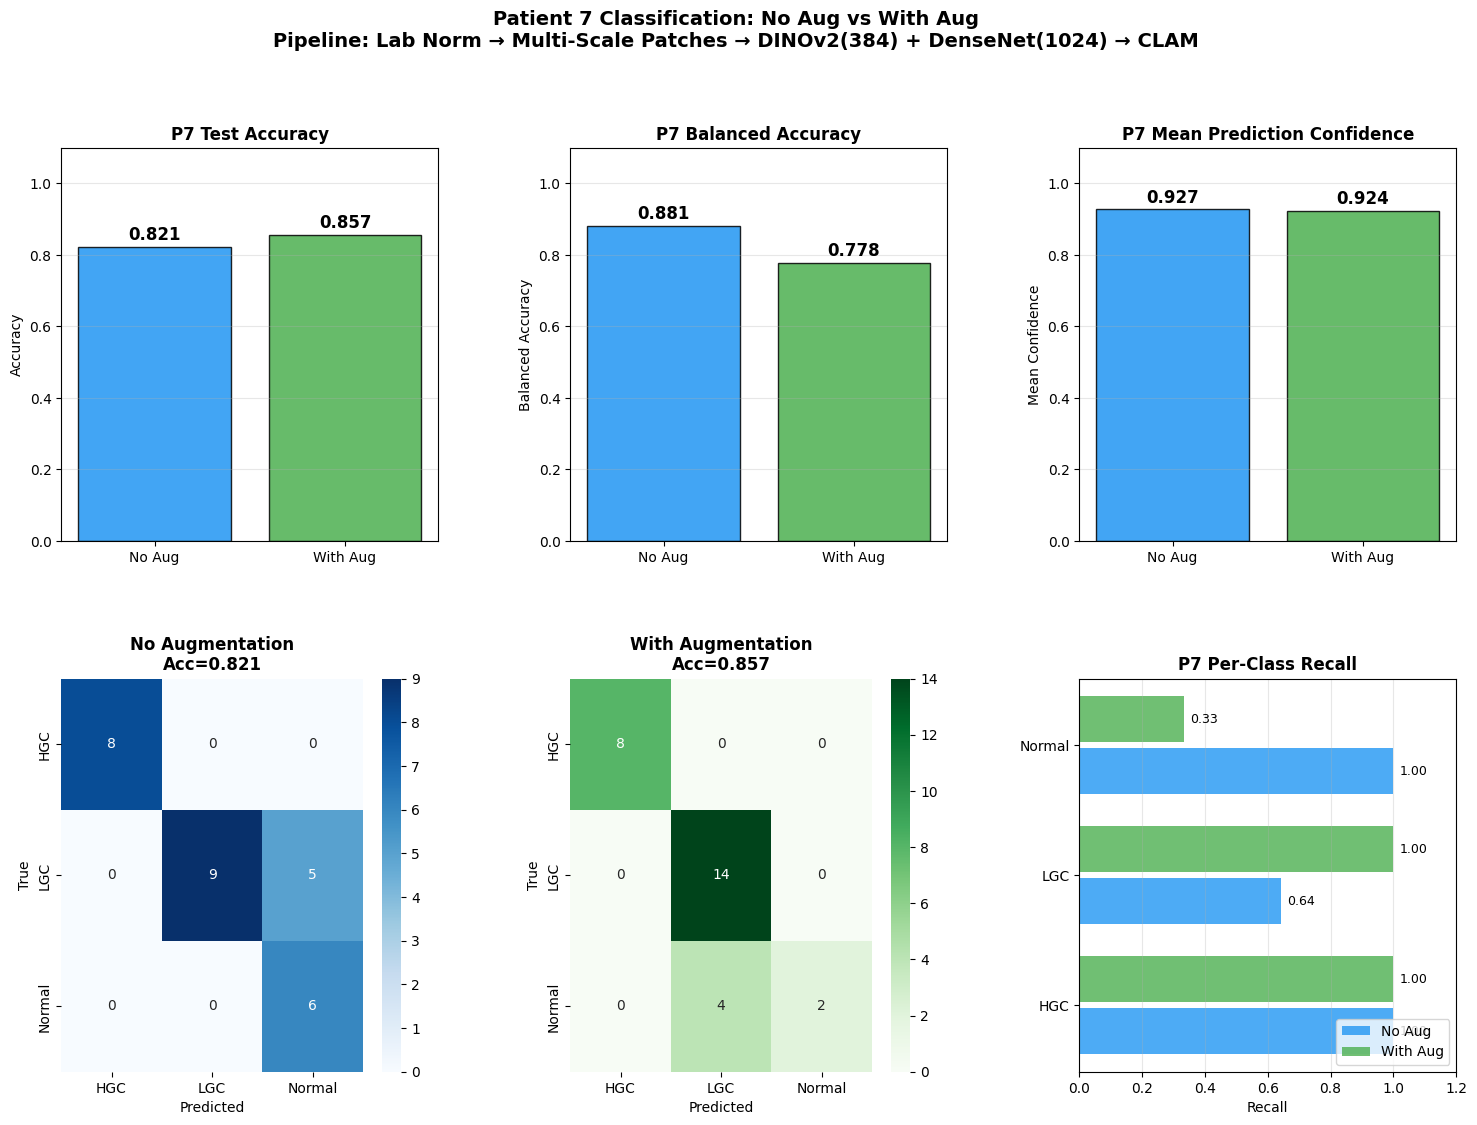

✓ Saved patient7_results.png


In [13]:
# ============================================================
# CELL 13: VISUALIZATION
# ============================================================

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.35)

# ---- 1. Accuracy comparison bars ----
ax1 = fig.add_subplot(gs[0, 0])
methods = ['No Aug', 'With Aug']
accs = [results_no_aug['accuracy'], results_with_aug['accuracy']]
colors = ['#2196F3', '#4CAF50']

bars = ax1.bar(methods, accs, color=colors, alpha=0.85, edgecolor='black', linewidth=1)
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.3f}', ha='center', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_title(f'P{CFG.target_patient} Test Accuracy', fontweight='bold')
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', alpha=0.3)

# ---- 2. Balanced accuracy comparison ----
ax2 = fig.add_subplot(gs[0, 1])
bal_accs = [results_no_aug['balanced_accuracy'], results_with_aug['balanced_accuracy']]
bars = ax2.bar(methods, bal_accs, color=colors, alpha=0.85, edgecolor='black', linewidth=1)
for bar, acc in zip(bars, bal_accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.3f}', ha='center', fontsize=12, fontweight='bold')
ax2.set_ylabel('Balanced Accuracy')
ax2.set_title(f'P{CFG.target_patient} Balanced Accuracy', fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.grid(axis='y', alpha=0.3)

# ---- 3. Confidence comparison ----
ax3 = fig.add_subplot(gs[0, 2])
confs = [results_no_aug['mean_confidence'], results_with_aug['mean_confidence']]
bars = ax3.bar(methods, confs, color=colors, alpha=0.85, edgecolor='black', linewidth=1)
for bar, conf in zip(bars, confs):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{conf:.3f}', ha='center', fontsize=12, fontweight='bold')
ax3.set_ylabel('Mean Confidence')
ax3.set_title(f'P{CFG.target_patient} Mean Prediction Confidence', fontweight='bold')
ax3.set_ylim(0, 1.1)
ax3.grid(axis='y', alpha=0.3)

# ---- 4. Confusion matrix - No aug ----
ax4 = fig.add_subplot(gs[1, 0])
cm1 = np.array(results_no_aug['confusion_matrix'])
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=CFG.class_names, yticklabels=CFG.class_names, ax=ax4)
ax4.set_xlabel('Predicted'); ax4.set_ylabel('True')
ax4.set_title(f'No Augmentation\nAcc={results_no_aug["accuracy"]:.3f}', fontweight='bold')

# ---- 5. Confusion matrix - With aug ----
ax5 = fig.add_subplot(gs[1, 1])
cm2 = np.array(results_with_aug['confusion_matrix'])
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=CFG.class_names, yticklabels=CFG.class_names, ax=ax5)
ax5.set_xlabel('Predicted'); ax5.set_ylabel('True')
ax5.set_title(f'With Augmentation\nAcc={results_with_aug["accuracy"]:.3f}', fontweight='bold')

# ---- 6. Per-class recall comparison ----
ax6 = fig.add_subplot(gs[1, 2])
na_recall = []
wa_recall = []
for i in range(CFG.num_classes):
    na_total = cm1[i].sum()
    wa_total = cm2[i].sum()
    na_recall.append(cm1[i, i] / max(na_total, 1))
    wa_recall.append(cm2[i, i] / max(wa_total, 1))

y_pos = np.arange(CFG.num_classes)
ax6.barh(y_pos - 0.2, na_recall, 0.35, label='No Aug',
         color='#2196F3', alpha=0.8)
ax6.barh(y_pos + 0.2, wa_recall, 0.35, label='With Aug',
         color='#4CAF50', alpha=0.8)
for i in range(CFG.num_classes):
    ax6.text(na_recall[i] + 0.02, i - 0.2, f'{na_recall[i]:.2f}',
             va='center', fontsize=9)
    ax6.text(wa_recall[i] + 0.02, i + 0.2, f'{wa_recall[i]:.2f}',
             va='center', fontsize=9)
ax6.set_yticks(y_pos)
ax6.set_yticklabels(CFG.class_names)
ax6.set_xlabel('Recall')
ax6.set_title(f'P{CFG.target_patient} Per-Class Recall', fontweight='bold')
ax6.legend(loc='lower right')
ax6.set_xlim(0, 1.2)
ax6.grid(axis='x', alpha=0.3)

fig.suptitle(
    f'Patient {CFG.target_patient} Classification: No Aug vs With Aug\n'
    f'Pipeline: Lab Norm → Multi-Scale Patches → {backbone_desc} → CLAM',
    fontsize=14, fontweight='bold', y=0.995
)
plt.savefig(f'patient{CFG.target_patient}_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved patient{CFG.target_patient}_results.png")

In [14]:
# ============================================================
# CELL 14: FINAL SUMMARY + EXPORT
# ============================================================

delta_acc = results_with_aug['accuracy'] - results_no_aug['accuracy']
delta_bal = results_with_aug['balanced_accuracy'] - results_no_aug['balanced_accuracy']

print(f"""
{'='*70}
  FINAL RESULTS - PATIENT {CFG.target_patient}
{'='*70}

  Pipeline: Lab Norm → Multi-Scale Patches → {backbone_desc} → CLAM
  Training: {len(train_df)} images from {len(TRAIN_PATIENTS)} patients (excluding P{CFG.target_patient})
  Testing: {len(test_df)} images from P{CFG.target_patient}
  Ensemble: {CFG.n_ensemble} seeds
  Early stopping: patience={CFG.patience}
  Class-weighted loss: Yes

  ┌──────────────────────────┬──────────────────┬──────────────────┐
  │ Metric                   │ No Augmentation  │ With Augmentation│
  ├──────────────────────────┼──────────────────┼──────────────────┤
  │ Accuracy                 │ {results_no_aug['accuracy']:.4f}           │ {results_with_aug['accuracy']:.4f}           │
  │ Balanced Accuracy        │ {results_no_aug['balanced_accuracy']:.4f}           │ {results_with_aug['balanced_accuracy']:.4f}           │
  │ Mean Confidence          │ {results_no_aug['mean_confidence']:.4f}           │ {results_with_aug['mean_confidence']:.4f}           │
  │ Correct/Total            │ {results_no_aug['correct']}/{results_no_aug['total']:<15} │ {results_with_aug['correct']}/{results_with_aug['total']:<15} │
  │ Training Time (min)      │ {results_no_aug['training_time_minutes']:.1f}              │ {results_with_aug['training_time_minutes']:.1f}              │
  ├──────────────────────────┼──────────────────┴──────────────────┤
  │ Δ Accuracy               │ {delta_acc:+.4f}                            │
  │ Δ Balanced Accuracy      │ {delta_bal:+.4f}                            │
  └──────────────────────────┴─────────────────────────────────────┘

  Test set distribution (P{CFG.target_patient}):
""")

for cls, count in sorted(results_no_aug['test_distribution'].items()):
    pct = count / results_no_aug['total'] * 100
    print(f"    {cls}: {count} images ({pct:.1f}%)")

print(f"""
  Total runtime: {total_time/60:.1f} minutes

{'='*70}
""")

# ---- Save JSON ----
summary = {
    'patient': CFG.target_patient,
    'pipeline': f'Lab_Norm + MultiScale + {backbone_desc} + CLAM',
    'classes': CFG.class_names,
    'n_train_patients': len(TRAIN_PATIENTS),
    'n_train_images': len(train_df),
    'n_test_images': len(test_df),
    'test_distribution': results_no_aug['test_distribution'],
    'no_augmentation': results_no_aug,
    'with_augmentation': results_with_aug,
    'comparison': {
        'delta_accuracy': float(delta_acc),
        'delta_balanced_accuracy': float(delta_bal)
    },
    'config': {
        'patch_scales': CFG.patch_scales,
        'max_patches_per_image': CFG.max_patches_per_image,
        'feature_dim': CFG.feat_dim,
        'backbone': backbone_desc,
        'mil_model': 'CLAM',
        'clam_k_sample': CFG.clam_k_sample,
        'epochs': CFG.epochs,
        'early_stopping_patience': CFG.patience,
        'lr': CFG.lr,
        'n_ensemble': CFG.n_ensemble,
        'n_augments': CFG.n_augments,
        'class_weighted_loss': True,
        'augmentations': [
            'rotation_360', 'hflip', 'vflip',
            'color_jitter(b=0.2,c=0.2,s=0.15,h=0.01)',
            'gaussian_blur(p=0.2)',
            'gaussian_noise(p=0.15)',
            'affine(t=0.05,s=0.95-1.05)'
        ],
        'total_runtime_minutes': total_time / 60
    }
}

with open(f'patient{CFG.target_patient}_results.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print(f"✓ Saved patient{CFG.target_patient}_results.json")

# ---- Save detailed CSV ----
rows = []
for i in range(len(test_data)):
    rows.append({
        'image_path': test_data[i]['path'],
        'true_label': test_data[i]['label_name'],
        'true_idx': results_no_aug['y_true'][i],
        'no_aug_pred': CFG.class_names[results_no_aug['y_pred'][i]],
        'no_aug_pred_idx': results_no_aug['y_pred'][i],
        'no_aug_correct': results_no_aug['y_true'][i] == results_no_aug['y_pred'][i],
        'aug_pred': CFG.class_names[results_with_aug['y_pred'][i]],
        'aug_pred_idx': results_with_aug['y_pred'][i],
        'aug_correct': results_with_aug['y_true'][i] == results_with_aug['y_pred'][i]
    })
    # Add probabilities for each class
    for c_idx, c_name in enumerate(CFG.class_names):
        rows[-1][f'no_aug_prob_{c_name}'] = round(results_no_aug['y_probs'][i][c_idx], 4)
        rows[-1][f'aug_prob_{c_name}'] = round(results_with_aug['y_probs'][i][c_idx], 4)

pd.DataFrame(rows).to_csv(f'patient{CFG.target_patient}_predictions.csv', index=False)
print(f"✓ Saved patient{CFG.target_patient}_predictions.csv")

# ---- Save classification reports ----
with open(f'patient{CFG.target_patient}_classification_report_no_aug.txt', 'w') as f:
    f.write(f"PATIENT {CFG.target_patient} - WITHOUT AUGMENTATION\n{'='*50}\n\n")
    f.write(classification_report(
        results_no_aug['y_true'], results_no_aug['y_pred'],
        target_names=CFG.class_names, zero_division=0
    ))

with open(f'patient{CFG.target_patient}_classification_report_with_aug.txt', 'w') as f:
    f.write(f"PATIENT {CFG.target_patient} - WITH AUGMENTATION\n{'='*50}\n\n")
    f.write(classification_report(
        results_with_aug['y_true'], results_with_aug['y_pred'],
        target_names=CFG.class_names, zero_division=0
    ))

print(f"✓ Saved classification reports")
print(f"\n{'='*70}")
print("  ALL DONE")
print(f"{'='*70}")


  FINAL RESULTS - PATIENT 7

  Pipeline: Lab Norm → Multi-Scale Patches → DINOv2(384) + DenseNet(1024) → CLAM
  Training: 1685 images from 13 patients (excluding P7)
  Testing: 28 images from P7
  Ensemble: 3 seeds
  Early stopping: patience=15
  Class-weighted loss: Yes

  ┌──────────────────────────┬──────────────────┬──────────────────┐
  │ Metric                   │ No Augmentation  │ With Augmentation│
  ├──────────────────────────┼──────────────────┼──────────────────┤
  │ Accuracy                 │ 0.8214           │ 0.8571           │
  │ Balanced Accuracy        │ 0.8810           │ 0.7778           │
  │ Mean Confidence          │ 0.9274           │ 0.9238           │
  │ Correct/Total            │ 23/28              │ 24/28              │
  │ Training Time (min)      │ 6.8              │ 10.7              │
  ├──────────────────────────┼──────────────────┴──────────────────┤
  │ Δ Accuracy               │ +0.0357                            │
  │ Δ Balanced Accuracy      │ -